In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [4]:
train_df = pd.read_stata("wage1(1).dta")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   wage      526 non-null    float32
 1   educ      526 non-null    int8   
 2   exper     526 non-null    int8   
 3   tenure    526 non-null    int8   
 4   nonwhite  526 non-null    int8   
 5   female    526 non-null    int8   
 6   married   526 non-null    int8   
 7   numdep    526 non-null    int8   
 8   smsa      526 non-null    int8   
 9   northcen  526 non-null    int8   
 10  south     526 non-null    int8   
 11  west      526 non-null    int8   
 12  construc  526 non-null    int8   
 13  ndurman   526 non-null    int8   
 14  trcommpu  526 non-null    int8   
 15  trade     526 non-null    int8   
 16  services  526 non-null    int8   
 17  profserv  526 non-null    int8   
 18  profocc   526 non-null    int8   
 19  clerocc   526 non-null    int8   
 20  servocc   526 non-null    int8  

In [5]:
train_df.head()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,1.131402,4,0
1,3.24,12,22,2,0,1,1,3,1,0,...,0,0,1,0,0,0,1,1.175573,484,4
2,3.00,11,2,0,0,0,0,2,0,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1.667707,49,4


In [6]:
train_df.describe()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
count,526.000000,526.000000,526.00000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,...,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000
mean,5.896103,12.562738,17.01711,5.104563,0.102662,0.479087,0.608365,1.043726,0.722433,0.250951,...,0.043726,0.287072,0.100760,0.258555,0.366920,0.167300,0.140684,1.623268,473.435361,78.150190
std,3.693085,2.769022,13.57216,7.224462,0.303805,0.500038,0.488580,1.261891,0.448225,0.433973,...,0.204680,0.452826,0.301298,0.438257,0.482423,0.373599,0.348027,0.531538,616.044772,199.434664
min,0.530000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.634878,1.000000,0.000000
25%,3.330000,12.000000,5.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.202972,25.000000,0.000000
50%,4.650000,12.000000,13.50000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.536867,182.500000,4.000000
75%,6.880000,14.000000,26.00000,7.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.750000,...,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.928619,676.000000,49.000000
max,24.980000,18.000000,51.00000,44.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.218076,2601.000000,1936.000000


In [17]:
X = train_df.drop(columns=['wage', 'lwage'])
y = train_df['wage']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

# train and dev 
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Dev:   {X_dev.shape}")
print(f"Test:  {X_test.shape}")

Train: (379, 22)
Dev:   (68, 22)
Test:  (79, 22)


In [18]:
numeric_cols = ['educ', 'exper', 'tenure', 'numdep']
scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])
X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_dev[numeric_cols] = scaler.transform(X_dev[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train[numeric_cols].describe())

               educ         exper        tenure        numdep
count  3.790000e+02  3.790000e+02  3.790000e+02  3.790000e+02
mean  -1.031131e-16  1.195174e-16 -6.561740e-17  3.398044e-17
std    1.001322e+00  1.001322e+00  1.001322e+00  1.001322e+00
min   -4.611070e+00 -1.173219e+00 -7.161549e-01 -8.092059e-01
25%   -2.228829e-01 -8.797208e-01 -7.161549e-01 -8.092059e-01
50%   -2.228829e-01 -2.927240e-01 -4.212904e-01 -2.080221e-02
75%    5.084817e-01  6.978331e-01  1.684384e-01  7.676015e-01
max    1.971211e+00  2.348762e+00  5.770862e+00  3.921216e+00


5.831321670650788 0.19560956304563815
exper       2.226423
profocc     1.972298
tenure      1.424658
educ        1.062546
smsa        0.675629
clerocc     0.389999
west        0.343542
numdep      0.072228
construc    0.060191
married     0.006164
tenursq    -0.001881
expersq    -0.003430
south      -0.030749
servocc    -0.045691
nonwhite   -0.402408
northcen   -0.481225
ndurman    -0.774376
profserv   -1.089807
trcommpu   -1.359413
female     -1.483229
services   -1.933388
trade      -2.040967
dtype: float64


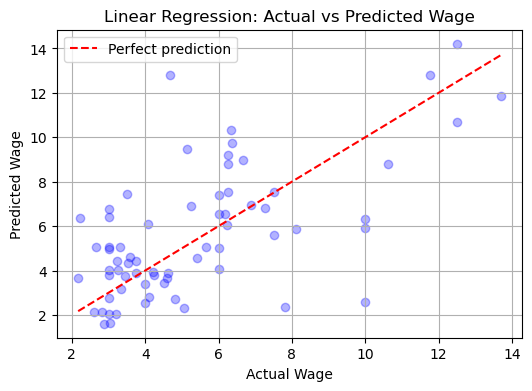

In [21]:
#linear regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_dev_pred = lr.predict(X_dev)

mse = mean_squared_error(y_dev, y_dev_pred)
r2 = r2_score(y_dev, y_dev_pred)

print(mse, r2)
coef = pd.Series(lr.coef_, index=X_train.columns)
print(coef.sort_values(ascending=False))

plt.figure(figsize=(6, 4))
plt.scatter(y_dev, y_dev_pred, alpha=0.3, color='blue')
plt.plot([y_dev.min(), y_dev.max()], [y_dev.min(), y_dev.max()], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual Wage")
plt.ylabel("Predicted Wage")
plt.title("Linear Regression: Actual vs Predicted Wage")
plt.legend()
plt.grid()
plt.show()

In [ ]:
#analysis
#Positive (increases wage):

#exper: +2.23 — experience has the biggest positive impact, each additional year adds $2.23/hr
#profocc: +1.97 — having a professional occupation adds $1.97/hr
#tenure: +1.42 — each year with current employer adds $1.42/hr
#educ: +1.06 — each extra year of education adds $1.06/hr
#smsa: +0.68 — living in a metropolitan area adds $0.68/hr

#Negative (decreases wage):

#female: -1.48 — being female reduces wage by $1.48/hr — this is the gender wage gap!
#trade: -2.04 — working in trade industry reduces wage by $2.04/hr
#services: -1.93 — service industry reduces wage by $1.93/hr
#nonwhite: -0.40 — racial wage gap of $0.40/hr

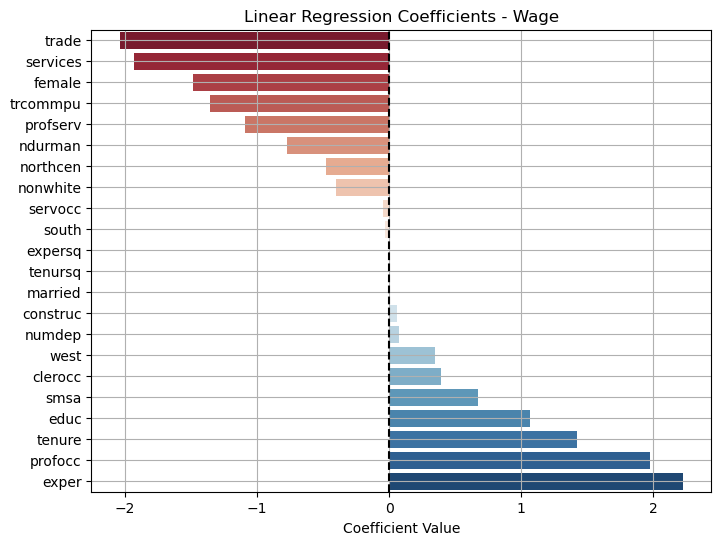

In [24]:
coef = pd.Series(lr.coef_, index=X_train.columns).sort_values()
plt.figure(figsize=(8, 6))
sns.barplot(x=coef.values, y=coef.index, palette='RdBu')
plt.axvline(0, color='black', linestyle='--')
plt.title("Linear Regression Coefficients - Wage")
plt.xlabel("Coefficient Value")
plt.grid()
plt.show()

9.057087537200786 3.0094995492939995 2.0511900476843237 -0.2493624967133352


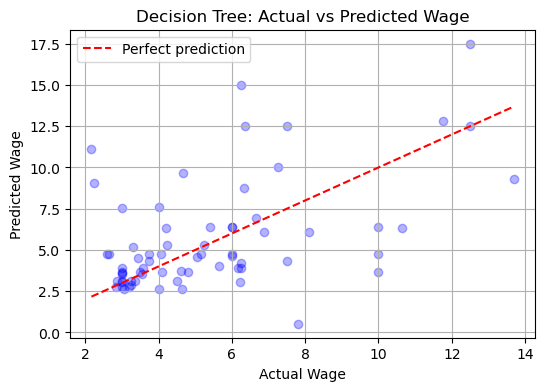

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42, max_depth=8)
dt.fit(X_train, y_train)

y_dev_pred_dt = dt.predict(X_dev)

mse = mean_squared_error(y_dev, y_dev_pred_dt)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_dev, y_dev_pred_dt)
r2 = r2_score(y_dev, y_dev_pred_dt)

print(mse, rmse, mae, r2)

plt.figure(figsize=(6, 4))
plt.scatter(y_dev, y_dev_pred_dt, alpha=0.3, color='blue')
plt.plot([y_dev.min(), y_dev.max()], [y_dev.min(), y_dev.max()], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual Wage")
plt.ylabel("Predicted Wage")
plt.title("Decision Tree: Actual vs Predicted Wage")
plt.legend()
plt.grid()
plt.show()

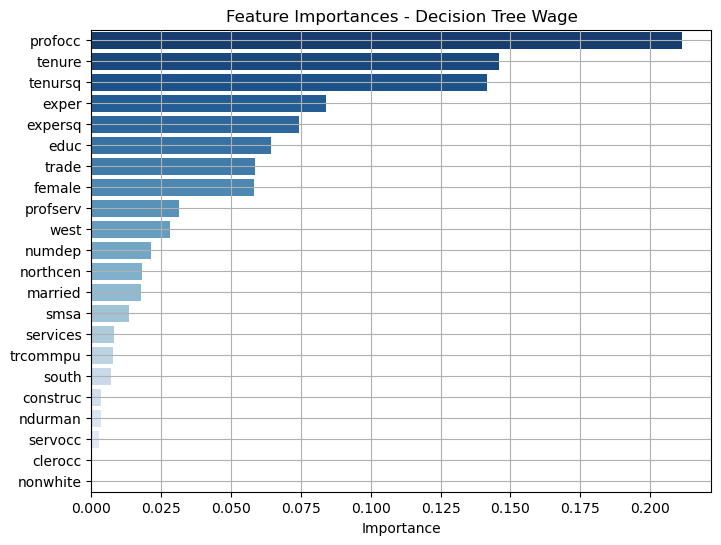

In [28]:
importances_dt = pd.Series(dt.feature_importances_, index=X_train.columns)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances_dt.sort_values(ascending=False).values,
            y=importances_dt.sort_values(ascending=False).index,
            palette='Blues_r')
plt.title("Feature Importances - Decision Tree Wage")
plt.xlabel("Importance")
plt.grid()
plt.show()

7.43370751930459 2.7264826277283687 1.8297005879021795 -0.025428466712762665


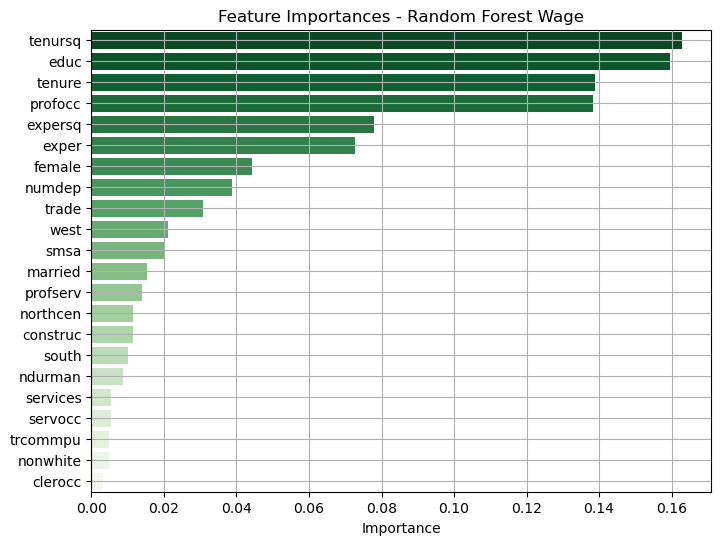

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

y_dev_pred_rf = rf.predict(X_dev)

mse = mean_squared_error(y_dev, y_dev_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_dev, y_dev_pred_rf)
r2 = r2_score(y_dev, y_dev_pred_rf)

print(mse, rmse, mae, r2)

importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances_rf.sort_values(ascending=False).values,
            y=importances_rf.sort_values(ascending=False).index,
            palette='Greens_r')
plt.title("Feature Importances - Random Forest Wage")
plt.xlabel("Importance")
plt.grid()
plt.show()

In [ ]:
#linear regression has the lowest amount of m2 which means is the most accurate one. 